# Phase 6B: Model-by-model review of lottery evidence

This notebook explains the saved Phase 6B review of models tested on past 3D Lotto 9PM and Lotto 6/42 results.

**Current assessment:** some small or weak patterns appeared in the historical data, but none of the tested methods showed a reliable improvement in predicting the complete next draw. The local Phase 6B decision is **NO_TESTED_MODEL_READY**.

This is a report on existing evidence. It does not train models, contact JEV, make number recommendations, or open the locked test.

## Sources and scope

The notebook reads saved aggregate reports only. Its Phase 6B sources are the five request evidence files, the Phase 6B summary, and the accompanying review note under reports/. It also reads the saved Phase 5A metric summary and Phase 5R aggregate evidence needed to explain the comparisons.

It does not load draw-history rows or locked-test target rows. It does not make network requests.

In [1]:
from pathlib import Path
import csv
import json
import math

import matplotlib.pyplot as plt

ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "reports" / "phase6b_model_semantic_summary.json").is_file()),
    None,
)
assert ROOT is not None, "Run this notebook from the repository or one of its subfolders."

PHASE6B_SOURCE_FILES = (
    "reports/phase6b_3d_semantic_adjudication.json",
    "reports/phase6b_3d_model_evidence.json",
    "reports/phase6b_642_semantic_adjudication.json",
    "reports/phase6b_642_model_evidence.json",
    "reports/phase6b_information_signal_adjudication.json",
    "reports/phase6b_model_semantic_summary.json",
    "reports/phase6b_model_semantic_review.md",
)
PHASE6B_JSON_FILES = PHASE6B_SOURCE_FILES[:-1]
PHASE5A_FILE = "reports/phase5a_metrics.json"
PHASE5R_FILE = "reports/phase5r_evidence.json"
SOURCE_FILES = (*PHASE6B_SOURCE_FILES, PHASE5A_FILE, PHASE5R_FILE)

assert all((ROOT / name).is_file() for name in SOURCE_FILES), "A saved report input is missing."

def read_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

phase6b_documents = {name: read_json(name) for name in PHASE6B_JSON_FILES}
phase6b_summary = phase6b_documents["reports/phase6b_model_semantic_summary.json"]
phase5a = read_json(PHASE5A_FILE)
phase5r = read_json(PHASE5R_FILE)
requests = {item["request_id"]: item for item in phase6b_summary["requests"]}
answers = {
    question_id: answer
    for request in phase6b_summary["requests"]
    for question_id, answer in request["answers"].items()
}
questions = {
    question_id: question
    for request in phase6b_summary["requests"]
    for question_id, question in request["questions"].items()
}

def answer(question_id):
    return answers[question_id]

def noul(question_id):
    result = answer(question_id)
    assert result["type"] == "noul"
    return float(result["noul"])

def choice(question_id):
    result = answer(question_id)
    assert result["type"] == "choice"
    return result

print(f"Loaded {len(PHASE6B_SOURCE_FILES)} Phase 6B references and two aggregate Phase 5 reports.")

Loaded 7 Phase 6B references and two aggregate Phase 5 reports.


In [2]:
expected_request_ids = {
    "3d_semantic", "3d_predictive", "642_semantic", "642_logistic",
    "642_random_forest", "642_shrinkage", "information_signal",
    "method_failure", "test_gate",
}
expected_noul = {
    "3d_target_matches_goal": 0.71,
    "3d_primary_metric_matches_goal": 0.85,
    "3d_secondary_overlap_is_primary_evidence": 0.13,
    "3d_logistic_beats_fair_probability_baseline": 0.19,
    "3d_logistic_improvement_temporally_stable": 0.30,
    "3d_shrinkage_beats_fair": 0.12,
    "642_target_matches_goal": 0.70,
    "642_primary_metric_matches_goal": 0.80,
    "642_hits_should_override_logscore": 0.11,
    "642_logistic_hit_gain_is_reliable": 0.19,
    "642_logistic_probability_quality_improved": 0.35,
    "642_logistic_calibration_is_acceptable": 0.12,
    "642_rf_beats_simple_baselines": 0.12,
    "642_shrinkage_reduces_overfit": 0.83,
    "642_shrinkage_beats_fair": 0.15,
    "642_mi_real_association_under_test": 0.73,
    "642_mi_establishes_predictive_utility": 0.20,
    "evidence_indicates_leakage": 0.22,
    "metrics_misaligned_with_goal": 0.39,
    "any_model_has_primary_metric_advantage": 0.53,
    "any_model_has_stable_temporal_advantage": 0.50,
    "any_model_ready_for_locked_test": 0.21,
}
expected_choices = {
    "3d_logistic_failure_interpretation": "SECONDARY_METRIC_ONLY",
    "642_logistic_failure_interpretation": "RANKING_SIGNAL_WITHOUT_PROBABILITY_SUPPORT",
    "642_rf_failure_interpretation": "WEAK_UNSTABLE_SIGNAL",
    "642_mi_interpretation": "SMALL_ASSOCIATION_WITHOUT_PREDICTIVE_GAIN",
    "primary_failure_source": "NO_DEMONSTRATED_SIGNAL",
}
expected_choice_distributions = {
    "3d_logistic_failure_interpretation": {
        "NO_OBSERVED_IMPROVEMENT": 0.35,
        "INSUFFICIENT_EVIDENCE": 0.01,
        "MODEL_SEMANTICS_INVALID": 0.09,
        "PREDICTIVE_IMPROVEMENT": 0.12,
        "SECONDARY_METRIC_ONLY": 0.43,
    },
    "642_logistic_failure_interpretation": {
        "INSUFFICIENT_EVIDENCE": 0.01,
        "RANKING_SIGNAL_WITHOUT_PROBABILITY_SUPPORT": 0.67,
        "PREDICTIVE_IMPROVEMENT": 0.01,
        "CALIBRATION_FAILURE": 0.10,
        "NO_OBSERVED_IMPROVEMENT": 0.21,
    },
    "642_rf_failure_interpretation": {
        "PREDICTIVE_IMPROVEMENT": 0.00,
        "WEAK_UNSTABLE_SIGNAL": 0.84,
        "NO_OBSERVED_IMPROVEMENT": 0.14,
        "INSUFFICIENT_EVIDENCE": 0.02,
    },
    "642_mi_interpretation": {
        "METHOD_INVALID": 0.01,
        "SMALL_ASSOCIATION_WITHOUT_PREDICTIVE_GAIN": 0.83,
        "LIKELY_RANDOM_FALSE_POSITIVE": 0.11,
        "VALIDATED_PREDICTIVE_SIGNAL": 0.05,
        "UNRESOLVED": 0.00,
    },
    "primary_failure_source": {
        "CALIBRATION_FAILURE": 0.01,
        "MODEL_MISSPECIFICATION": 0.00,
        "INSUFFICIENT_SAMPLE_POWER": 0.06,
        "VALIDATION_REUSE_LIMITATION": 0.01,
        "NO_DEMONSTRATED_SIGNAL": 0.91,
        "UNRESOLVED": 0.00,
        "MATERIAL_METHOD_DEFECT": 0.01,
    },
}

assert all(document["phase6b_status"] == "PHASE6B_MODEL_SEMANTIC_ADJUDICATION_COMPLETE"
           for document in phase6b_documents.values())
assert set(requests) == expected_request_ids
assert phase6b_summary["request_count"] == 9
assert all(item["model_identifier_returned"] == "jev-1.13.0" and item["http_status"] == 200
           for item in requests.values())
assert len(answers) == 27
assert set(answers) == set(expected_noul) | set(expected_choices)
assert sum(item["type"] == "noul" for item in answers.values()) == 22
assert sum(item["type"] == "choice" for item in answers.values()) == 5

for question_id, expected_value in expected_noul.items():
    assert answer(question_id)["type"] == "noul"
    assert math.isclose(noul(question_id), expected_value, abs_tol=1e-12)
    assert 0 <= noul(question_id) <= 1

for question_id, expected_value in expected_choices.items():
    result = choice(question_id)
    assert result["choice"] == expected_value
    actual_distribution = result["probabilities"]
    expected_distribution = expected_choice_distributions[question_id]
    assert set(actual_distribution) == set(expected_distribution)
    assert all(math.isclose(actual_distribution[key], value, abs_tol=1e-12)
               for key, value in expected_distribution.items())
    assert math.isclose(sum(actual_distribution.values()), 1.0, abs_tol=1e-12)

individual_files = (
    "reports/phase6b_3d_semantic_adjudication.json",
    "reports/phase6b_3d_model_evidence.json",
    "reports/phase6b_642_semantic_adjudication.json",
    "reports/phase6b_642_model_evidence.json",
    "reports/phase6b_information_signal_adjudication.json",
)
individual_requests = {
    request["request_id"]: request
    for name in individual_files
    for request in phase6b_documents[name]["requests"]
}
for request_id, saved_request in individual_requests.items():
    summary_request = requests[request_id]
    assert saved_request["state"] == summary_request["state"]
    assert saved_request["questions"] == summary_request["questions"]
    assert saved_request["answers"] == summary_request["answers"]

forbidden_prior_results = (
    "stop_no_reproducible_predictive_signal",
    "no_tested_model_ready",
    "phase6_jev_adjudication",
    "previous_phase6_status",
)
for request in requests.values():
    request_input = json.dumps(
        {"state": request["state"], "questions": request["questions"]},
        ensure_ascii=False,
    ).lower()
    assert not any(term in request_input for term in forbidden_prior_results)
assert phase6b_summary["validation"]["prior_phase6_not_in_request_states"] == "PASS"

locked_test = phase6b_summary["locked_test"]
assert locked_test == {
    "status": "SEALED",
    "target_rows_read": False,
    "scores_calculated": False,
    "predictions_generated": False,
}
local_classification = phase6b_summary["deterministic_aggregation"]["classification"]
assert local_classification == "NO_TESTED_MODEL_READY"
assert noul("any_model_ready_for_locked_test") <= 0.30

mi_rows = [
    row for row in phase5r["information_tests"]
    if row["game"] == "lotto_6_42"
    and row["diagnostic_family"] == "expanding_historical_frequency"
    and row["target_measure"] == "membership"
]
assert len(mi_rows) == 1
mi_result = mi_rows[0]
assert math.isclose(mi_result["observed_mutual_information_nats_per_candidate"],
                    0.0036796053644954176, abs_tol=1e-12)
assert math.isclose(mi_result["empirical_p_add_one"], 0.0036996300369963003, abs_tol=1e-12)
assert math.isclose(mi_result["bh_q_within_game"], 0.029597040295970403, abs_tol=1e-12)

print("Checks passed: 9 requests, 27 typed answers, 22 Noul answers, and 5 Choice distributions.")
print("All six Phase 6B JSON reports show the complete status; request inputs omit earlier Phase 6 results.")
print(f"Local classification: {local_classification}. Locked test: {locked_test['status']}.")
print("Only locked-test status metadata was read; no target rows, scores, or predictions were used.")

Checks passed: 9 requests, 27 typed answers, 22 Noul answers, and 5 Choice distributions.
All six Phase 6B JSON reports show the complete status; request inputs omit earlier Phase 6 results.
Local classification: NO_TESTED_MODEL_READY. Locked test: SEALED.
Only locked-test status metadata was read; no target rows, scores, or predictions were used.


## 1. Phase 6B Purpose

The earlier JEV review asked broad questions about the project as a whole. That made it harder to separate questions about a specific model, its target, and its score. Phase 6B asked separate questions for each tested model and evidence claim.

The main research question stayed the same: did information from past draws help predict the complete next draw better than a fair baseline, where every valid combination has the same chance?

## 2. How JEV Was Used

JEV acted as an evidence reviewer, not as a prediction model. Nine separate requests described the target, model, score, and saved validation evidence. All nine successful responses came from model jev-1.13.0.

Validation here means checking a model on later historical draws that were held out during fitting. JEV was not asked to choose the project's final status. The local status was calculated from a recorded rule. Earlier Phase 6 conclusions were not included in the new request states or questions, as checked above.

## 3. Understanding the JEV Answers

**Noul** is JEV's probability of answering yes to one exact question. It is not a scientific p-value and is not the chance that a lottery result will occur.

**Choice** asks JEV to select among named explanations. Its returned distribution shows how the answer was divided among those choices. The accompanying confidence field is described as information about that returned distribution, not scientific certainty.

These answers help organize the review. They do not replace the measured model results.

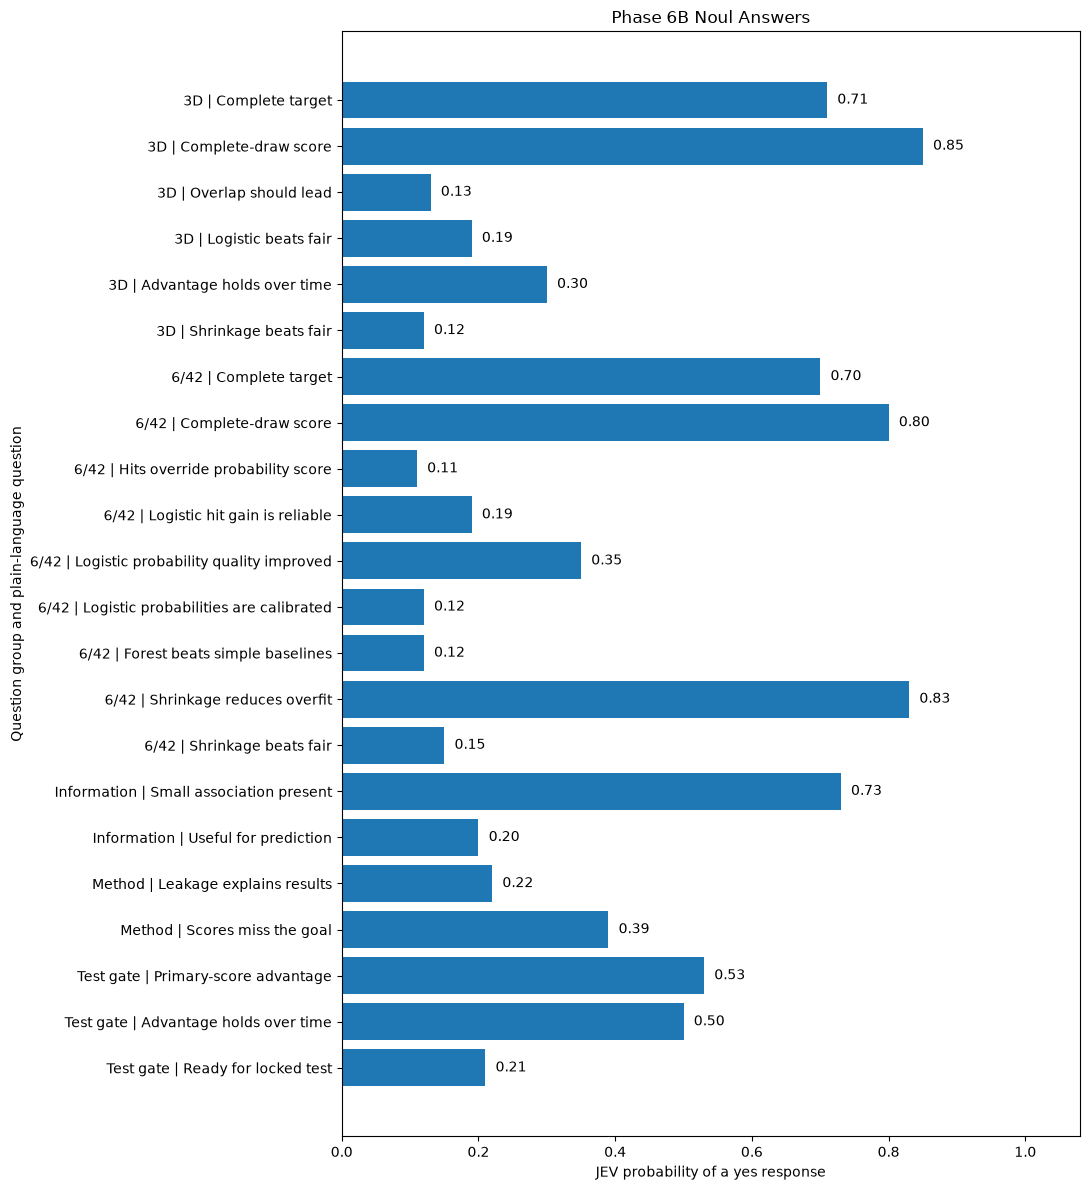

In [3]:
noul_chart_labels = {
    "3d_target_matches_goal": "3D | Complete target",
    "3d_primary_metric_matches_goal": "3D | Complete-draw score",
    "3d_secondary_overlap_is_primary_evidence": "3D | Overlap should lead",
    "3d_logistic_beats_fair_probability_baseline": "3D | Logistic beats fair",
    "3d_logistic_improvement_temporally_stable": "3D | Advantage holds over time",
    "3d_shrinkage_beats_fair": "3D | Shrinkage beats fair",
    "642_target_matches_goal": "6/42 | Complete target",
    "642_primary_metric_matches_goal": "6/42 | Complete-draw score",
    "642_hits_should_override_logscore": "6/42 | Hits override probability score",
    "642_logistic_hit_gain_is_reliable": "6/42 | Logistic hit gain is reliable",
    "642_logistic_probability_quality_improved": "6/42 | Logistic probability quality improved",
    "642_logistic_calibration_is_acceptable": "6/42 | Logistic probabilities are calibrated",
    "642_rf_beats_simple_baselines": "6/42 | Forest beats simple baselines",
    "642_shrinkage_reduces_overfit": "6/42 | Shrinkage reduces overfit",
    "642_shrinkage_beats_fair": "6/42 | Shrinkage beats fair",
    "642_mi_real_association_under_test": "Information | Small association present",
    "642_mi_establishes_predictive_utility": "Information | Useful for prediction",
    "evidence_indicates_leakage": "Method | Leakage explains results",
    "metrics_misaligned_with_goal": "Method | Scores miss the goal",
    "any_model_has_primary_metric_advantage": "Test gate | Primary-score advantage",
    "any_model_has_stable_temporal_advantage": "Test gate | Advantage holds over time",
    "any_model_ready_for_locked_test": "Test gate | Ready for locked test",
}
assert set(noul_chart_labels) == set(expected_noul)
chart_items = list(noul_chart_labels.items())
chart_labels = [label for _, label in chart_items]
chart_values = [noul(question_id) for question_id, _ in chart_items]

fig, ax = plt.subplots(figsize=(11, 12))
positions = range(len(chart_labels))
ax.barh(positions, chart_values)
ax.set_yticks(list(positions), chart_labels)
ax.invert_yaxis()
ax.set_xlim(0, 1.08)
ax.set_xlabel("JEV probability of a yes response")
ax.set_ylabel("Question group and plain-language question")
ax.set_title("Phase 6B Noul Answers")
for position, value in zip(positions, chart_values):
    ax.text(value + 0.015, position, f"{value:.2f}", va="center")
fig.tight_layout()
plt.show()
plt.close(fig)

The chart groups all 22 yes/no questions by 3D, Lotto 6/42, information signal, method review, and test gate. Values describe JEV's response to each question, not a chance of winning or a significance cutoff.

## 4. 3D Lotto Question and Model

A 3D result is treated as an unordered multiset of three digits. It does not matter what order the digits are written in, but repeated digits stay repeated.

The prediction goal is to assign a useful probability to the whole three-digit result. In Phase 6B, JEV rated the target fit at 0.71 and the complete-result score at 0.85. It rated the idea that digit overlap should replace the complete-result score at 0.13.

In [4]:
print("3D target and score questions:")
for question_id in (
    "3d_target_matches_goal",
    "3d_primary_metric_matches_goal",
    "3d_secondary_overlap_is_primary_evidence",
):
    print(f"  {question_id}: {noul(question_id):.2f}")

3D target and score questions:
  3d_target_matches_goal: 0.71
  3d_primary_metric_matches_goal: 0.85
  3d_secondary_overlap_is_primary_evidence: 0.13


## 5. 3D Lotto Model Assessment

The Phase 5A score measures how much probability the model gave to the complete unordered draw. Lower is better. The overlap score counts how many digits the suggested multiset shares with the actual draw, but it does not test the full probability assigned to that result.

In [5]:
three_metrics = phase5a["validation"]["3d_lotto"]["methods"]
three_rows = (
    ("Fair random", three_metrics["uniform_random"]),
    ("Expanding historical frequency", three_metrics["expanding_historical_frequency"]),
    ("Logistic model, all features", three_metrics["multinomial_logistic_regression/all_features"]),
)
print("3D Phase 5A development results")
print("Method                           Complete-draw score per digit   Digit overlap")
for label, row in three_rows:
    print(f"{label:<32} {row['mean_multinomial_negative_log_likelihood_per_digit']:>10.4f}                 "
          f"{row['mean_multiset_overlap']:.4f}")
print(f"JEV: beats fair={noul('3d_logistic_beats_fair_probability_baseline'):.2f}; "
      f"stable over time={noul('3d_logistic_improvement_temporally_stable'):.2f}")

3D Phase 5A development results
Method                           Complete-draw score per digit   Digit overlap
Fair random                          1.7733                 0.7426
Expanding historical frequency       1.7738                 0.8451
Logistic model, all features         1.8992                 0.7994
JEV: beats fair=0.19; stable over time=0.30


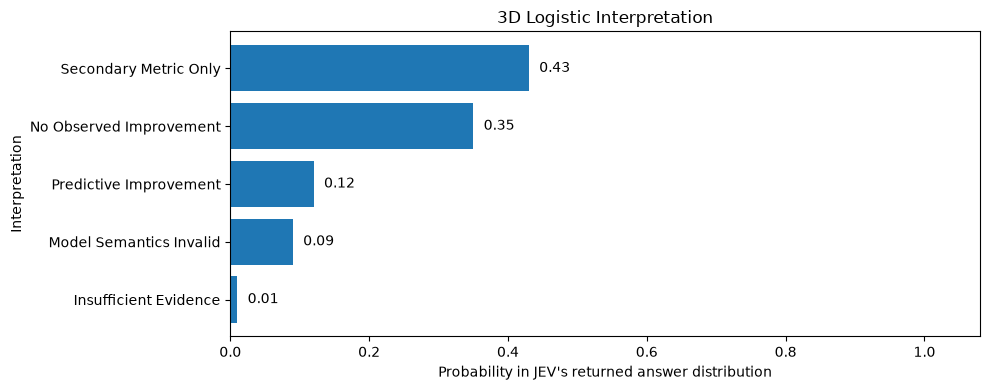

In [6]:
def plot_choice_distribution(question_id, title):
    result = choice(question_id)
    items = sorted(result["probabilities"].items(), key=lambda item: item[1], reverse=True)
    labels = [name.replace("_", " ").title() for name, _ in items]
    values = [value for _, value in items]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(labels))))
    positions = range(len(labels))
    ax.barh(positions, values)
    ax.set_yticks(list(positions), labels)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.08)
    ax.set_xlabel("Probability in JEV's returned answer distribution")
    ax.set_ylabel("Interpretation")
    ax.set_title(title)
    for position, value in zip(positions, values):
        ax.text(value + 0.015, position, f"{value:.2f}", va="center")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

plot_choice_distribution("3d_logistic_failure_interpretation", "3D Logistic Interpretation")

JEV selected **SECONDARY_METRIC_ONLY** at 0.43, with **NO_OBSERVED_IMPROVEMENT** at 0.35. That matches the measured results: the logistic model had higher digit overlap than fair random, but its complete-draw score was worse than both fair random and historical frequency. The overlap result therefore did not establish better complete-draw probability.

## 6. 3D Shrinkage Assessment

Shrinkage pulls uncertain historical estimates toward a fair starting point. Here, stronger shrinkage brought the historical model closer to fair performance, but no tested setting passed it.

In [7]:
three_full_scores = phase5r["combination_validation"]["3d_lotto"]["models"]
print("3D complete-combination probability score, lower is better")
three_score_labels = {
    "fair_random": "Fair random",
    "raw_expanding_frequency": "Historical frequency, no shrinkage",
    "dirichlet_kappa_10": "Shrinkage setting 10",
    "dirichlet_kappa_100": "Shrinkage setting 100",
    "dirichlet_kappa_1000": "Shrinkage setting 1000",
}
for model_name, label in three_score_labels.items():
    score = three_full_scores[model_name]["mean_combination_nll_nats"]
    print(f"  {label:<36} {score:.6f}")
print(f"JEV probability that a tested shrinkage setting beats fair: {noul('3d_shrinkage_beats_fair'):.2f}")

3D complete-combination probability score, lower is better
  Fair random                          5.319894
  Historical frequency, no shrinkage   5.321320
  Shrinkage setting 10                 5.321316
  Shrinkage setting 100                5.321281
  Shrinkage setting 1000               5.320988
JEV probability that a tested shrinkage setting beats fair: 0.12


The 0.12 Noul answer means JEV gave little support to the claim that any tested 3D shrinkage setting beat fair random. The scores show why: the strongest setting was closest to fair, but still had a slightly worse score.

## 7. Lotto 6/42 Question and Model

A Lotto 6/42 result is the complete unordered set of six distinct numbers. Ranking individual numbers can help choose a set, but a good ranking does not by itself show that the model assigned a good probability to the exact six-number result.

JEV rated the complete target fit at 0.70 and the complete-result score at 0.80. It rated the idea that a higher hits-at-6 average should override the complete-result score at 0.11.

In [8]:
print("Lotto 6/42 target and score questions:")
for question_id in (
    "642_target_matches_goal",
    "642_primary_metric_matches_goal",
    "642_hits_should_override_logscore",
):
    print(f"  {question_id}: {noul(question_id):.2f}")

Lotto 6/42 target and score questions:


  642_target_matches_goal: 0.70
  642_primary_metric_matches_goal: 0.80
  642_hits_should_override_logscore: 0.11


## 8. 6/42 Logistic Regression Assessment

The logistic model had a higher hits-at-6 average than fair random and historical frequency. The separate per-number probability score penalizes confident wrong chances, so lower is better. Its per-number probabilities were poorly calibrated. Calibration means that cases given similar chances should occur at about those rates over time.

The fair-simulation comparison checks how often repeated fair draws match or exceed the observed hit count. The saved value was 0.0827, and it was 0.1654 after allowing for the two tested model checks. These values are not chances of winning. The 95% resampling range for the hit difference versus fair was -0.0238 to 0.1562. Because it includes zero, the measured results are consistent with no gain.

A complete-set score checks probability assigned to whole six-number combinations. The logistic model's hits alone do not answer that question.

In [9]:
six_methods = phase5a["validation"]["lotto_6_42"]["methods"]
six_fair = six_methods["uniform_random"]
six_history = six_methods["expanding_historical_frequency"]
six_logistic = six_methods["regularized_one_vs_rest_logistic_regression/all_features"]
six_forest = six_methods["random_forest_multioutput_comparator/all_features"]
logistic_bootstrap = phase5a["bootstrap"]["games"]["lotto_6_42"][
    "regularized_one_vs_rest_logistic_regression"
]
print("6/42 Phase 5A results")
print("Method                 Hits at 6   Per-number score   Calibration error")
for label, row in (
    ("Fair random", six_fair),
    ("Historical frequency", six_history),
    ("Logistic, all features", six_logistic),
    ("Random forest, all features", six_forest),
):
    ece = row["calibration"]["expected_calibration_error"]
    print(f"{label:<25} {row['mean_hits_at_6']:.4f}       "
          f"{row['mean_marginal_log_loss']:.4f}             {ece:.4f}")
random_comparison = phase5a["random_baseline"]["games"]["lotto_6_42"][
    "candidates"]["regularized_one_vs_rest_logistic_regression"]
diff_ci = logistic_bootstrap["difference_vs_fair_random_ci95"]
print(f"Fair-simulation comparison: {random_comparison['empirical_p_final']:.4f}; "
      f"after allowing for two model checks: {random_comparison['empirical_p_bonferroni']:.4f}")
print(f"95% resampling range for hit difference vs fair: "
      f"[{diff_ci['lower']:.4f}, {diff_ci['upper']:.4f}]")
print("JEV answers: hit gain reliable="
      f"{noul('642_logistic_hit_gain_is_reliable'):.2f}, probability quality improved="
      f"{noul('642_logistic_probability_quality_improved'):.2f}, calibration acceptable="
      f"{noul('642_logistic_calibration_is_acceptable'):.2f}")

6/42 Phase 5A results
Method                 Hits at 6   Per-number score   Calibration error
Fair random               0.8571       0.4101             0.0000
Historical frequency      0.9000       0.4107             0.0000
Logistic, all features    0.9233       2.6048             0.3787
Random forest, all features 0.8833       0.4130             0.0037
Fair-simulation comparison: 0.0827; after allowing for two model checks: 0.1654
95% resampling range for hit difference vs fair: [-0.0238, 0.1562]
JEV answers: hit gain reliable=0.19, probability quality improved=0.35, calibration acceptable=0.12


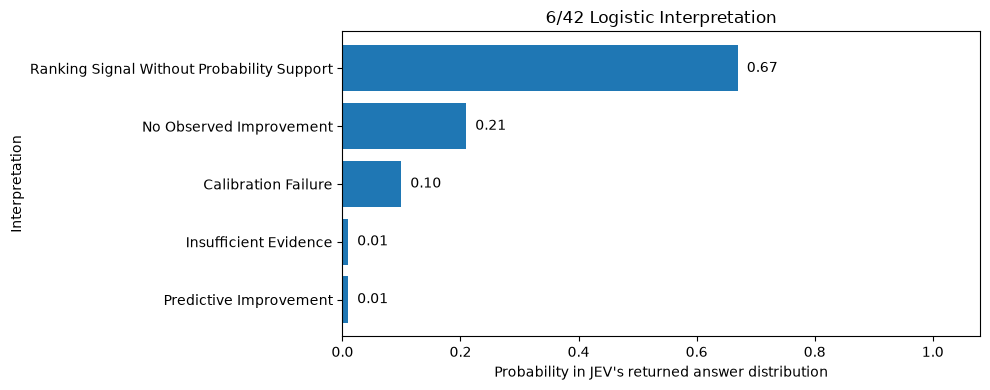

In [10]:
plot_choice_distribution("642_logistic_failure_interpretation", "6/42 Logistic Interpretation")

JEV selected **RANKING_SIGNAL_WITHOUT_PROBABILITY_SUPPORT** at 0.67. In plain terms, the model's list of six numbers had a higher average match count, but the evidence did not show reliable improvement in assigning probability to future results. The bootstrap range crosses zero, and the chance-adjusted comparison and calibration also weaken the claim. A higher hits-at-6 point estimate alone is not enough.

## 9. 6/42 Random Forest Assessment

The random forest is a second model for ranking numbers. Its average hits were close to the fair baseline and below the historical-frequency baseline. Its per-number probability score did not show an advantage.

In [11]:
forest_random_comparison = phase5a["random_baseline"]["games"]["lotto_6_42"][
    "candidates"]["random_forest_multioutput_comparator"]
print(f"Fair random hits at 6: {six_fair['mean_hits_at_6']:.4f}")
print(f"Historical frequency hits at 6: {six_history['mean_hits_at_6']:.4f}")
print(f"Random forest hits at 6: {six_forest['mean_hits_at_6']:.4f}")
print(f"Random forest marginal log loss: {six_forest['mean_marginal_log_loss']:.4f}")
print(f"Random forest per-number calibration error: "
      f"{six_forest['calibration']['expected_calibration_error']:.4f}")
print(f"Random-simulation p={forest_random_comparison['empirical_p_final']:.4f}; "
      f"two-model adjusted p={forest_random_comparison['empirical_p_bonferroni']:.4f}")
print(f"JEV probability it beats simple baselines: {noul('642_rf_beats_simple_baselines'):.2f}")

Fair random hits at 6: 0.8571
Historical frequency hits at 6: 0.9000
Random forest hits at 6: 0.8833
Random forest marginal log loss: 0.4130
Random forest per-number calibration error: 0.0037
Random-simulation p=0.2932; two-model adjusted p=0.5863
JEV probability it beats simple baselines: 0.12


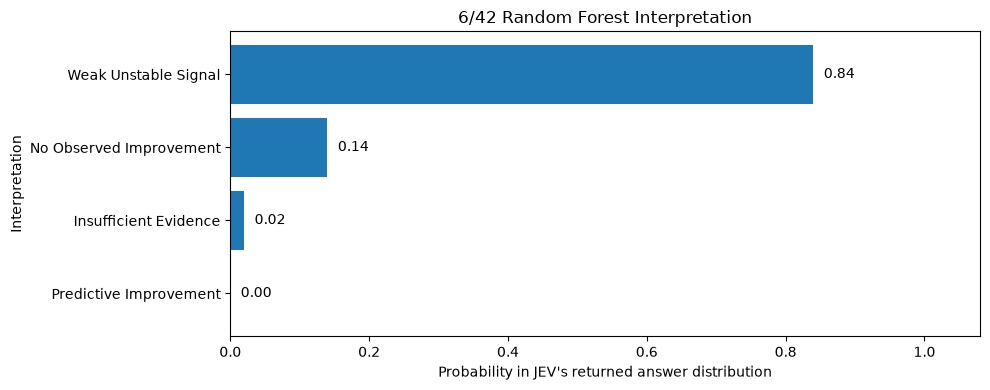

In [12]:
plot_choice_distribution("642_rf_failure_interpretation", "6/42 Random Forest Interpretation")

JEV selected **WEAK_UNSTABLE_SIGNAL** at 0.84. That means the returned answer leaned toward a small, inconsistent pattern rather than a dependable improvement. A low per-number calibration error does not prove better probabilities for complete six-number sets.

## 10. 6/42 Shrinkage Assessment

Stronger shrinkage moved the historical-frequency model closer to fair performance. Overfit means matching the past too closely in a way that does not hold up on later draws. The complete-set score still remained worse than fair random.

In [13]:
six_full_scores = phase5r["combination_validation"]["lotto_6_42"]["models"]
print("6/42 complete-combination probability score, lower is better")
six_score_labels = {
    "fair_random": "Fair random",
    "raw_expanding_frequency": "Historical frequency, no shrinkage",
    "beta_kappa_10": "Shrinkage setting 10",
    "beta_kappa_100": "Shrinkage setting 100",
    "beta_kappa_1000": "Shrinkage setting 1000",
}
for model_name, label in six_score_labels.items():
    score = six_full_scores[model_name]["mean_combination_nll_nats"]
    print(f"  {label:<36} {score:.6f}")
print(f"JEV probability shrinkage reduces overfit: "
      f"{noul('642_shrinkage_reduces_overfit'):.2f}")
print(f"JEV probability a setting beats fair: {noul('642_shrinkage_beats_fair'):.2f}")

6/42 complete-combination probability score, lower is better
  Fair random                          15.472936
  Historical frequency, no shrinkage   15.497953
  Shrinkage setting 10                 15.497611
  Shrinkage setting 100                15.494869
  Shrinkage setting 1000               15.482702
JEV probability shrinkage reduces overfit: 0.83
JEV probability a setting beats fair: 0.15


The 0.83 answer supports the claim that shrinkage reduced the historical model's excess. The 0.15 answer gives little support to beating fair random. Moving a weak model closer to fair performance is not the same as showing an advantage over fair.

## 11. Small 6/42 Information Signal

The expanding-frequency check found a small association between past frequency and later number membership. Mutual information is a measure of how much knowing one thing changes what we know about another. The unit, nats per candidate, is a way to report that amount.

The saved result was **0.00368 nats per candidate**. Nats are a unit for measuring information. The shuffled-history comparison, called a p-value, was **0.00370**. It compares the result with histories shuffled while each draw stays intact. A result this strong was uncommon under that comparison. The multiple-pattern adjusted value, called a q-value, was **0.02960**. It accounts for checking many related patterns. Neither value shows that the association helps predict a full future combination.

In [14]:
print(f"Observed mutual information: "
      f"{mi_result['observed_mutual_information_nats_per_candidate']:.5f} nats per candidate")
print(f"Shuffled-history comparison (p-value): {mi_result['empirical_p_add_one']:.5f}")
print(f"Multiple-pattern adjusted value (q-value): {mi_result['bh_q_within_game']:.5f}")
print(f"JEV probability of a small association: "
      f"{noul('642_mi_real_association_under_test'):.2f}")
print(f"JEV probability of predictive usefulness: "
      f"{noul('642_mi_establishes_predictive_utility'):.2f}")

Observed mutual information: 0.00368 nats per candidate
Shuffled-history comparison (p-value): 0.00370
Multiple-pattern adjusted value (q-value): 0.02960
JEV probability of a small association: 0.73
JEV probability of predictive usefulness: 0.20


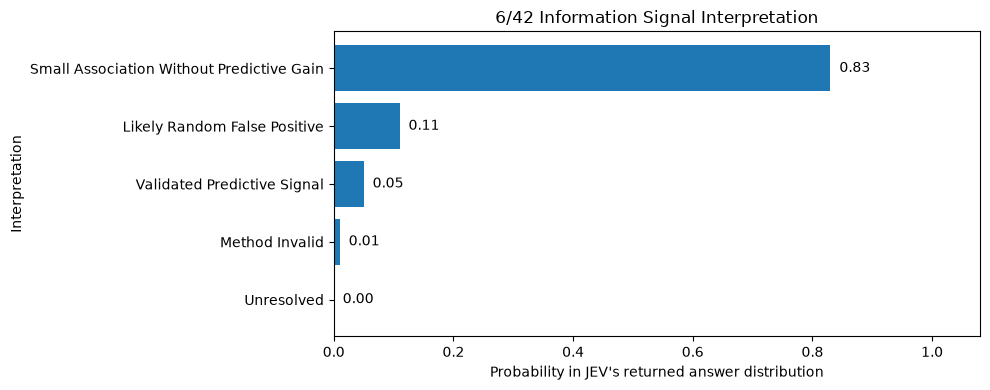

In [15]:
plot_choice_distribution("642_mi_interpretation", "6/42 Information Signal Interpretation")

JEV selected **SMALL_ASSOCIATION_WITHOUT_PREDICTIVE_GAIN** at 0.83. The chronological complete-result comparisons did not improve over fair random, so the small association did not become a demonstrated prediction advantage.

## 12. Was the Method Itself Broken?

Phase 6B also asked whether the results could be explained by information leaking from the future, or by using scores that missed the goal. A leakage check tests whether future results accidentally influenced earlier estimates. A misaligned score rewards something other than the complete next draw.

In [16]:
print(f"JEV probability the evidence indicates leakage: "
      f"{noul('evidence_indicates_leakage'):.2f}")
print(f"JEV probability the scores are misaligned with the goal: "
      f"{noul('metrics_misaligned_with_goal'):.2f}")

JEV probability the evidence indicates leakage: 0.22
JEV probability the scores are misaligned with the goal: 0.39


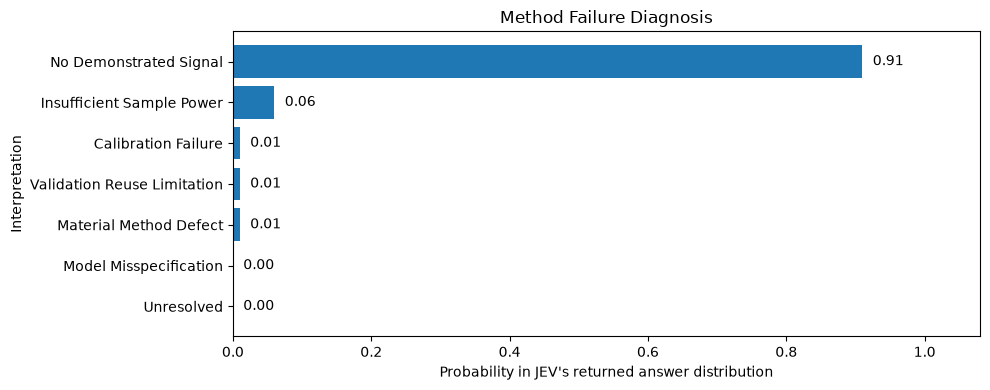

In [17]:
plot_choice_distribution("primary_failure_source", "Method Failure Diagnosis")

JEV selected **NO_DEMONSTRATED_SIGNAL** at 0.91. Leakage and score mismatch received lower yes probabilities, at 0.22 and 0.39. This favors the simple explanation that the tested methods did not demonstrate a reliable signal. It does not prove that no signal exists.

## 13. Locked Test Readiness

The three gate questions received Noul values of 0.53 for a primary-score advantage, 0.50 for a stable advantage over time, and 0.21 for readiness for the locked test. The first two answers are uncertain. The readiness answer is low.

The local summary rule assigns **NO_TESTED_MODEL_READY** when readiness is 0.30 or lower. The saved value is 0.21. This classification was computed locally; JEV did not choose it.

In [18]:
print(f"Primary-score advantage: {noul('any_model_has_primary_metric_advantage'):.2f}")
print(f"Stable advantage over time: {noul('any_model_has_stable_temporal_advantage'):.2f}")
print(f"Ready for locked test: {noul('any_model_ready_for_locked_test'):.2f}")
print("Local aggregation rule: readiness at or below 0.30 gives NO_TESTED_MODEL_READY.")
print(f"Saved local classification: {local_classification}")
print(f"Locked-test status: {locked_test['status']}; "
      f"target rows read={locked_test['target_rows_read']}; "
      f"scores calculated={locked_test['scores_calculated']}; "
      f"predictions generated={locked_test['predictions_generated']}.")

Primary-score advantage: 0.53
Stable advantage over time: 0.50
Ready for locked test: 0.21
Local aggregation rule: readiness at or below 0.30 gives NO_TESTED_MODEL_READY.
Saved local classification: NO_TESTED_MODEL_READY
Locked-test status: SEALED; target rows read=False; scores calculated=False; predictions generated=False.


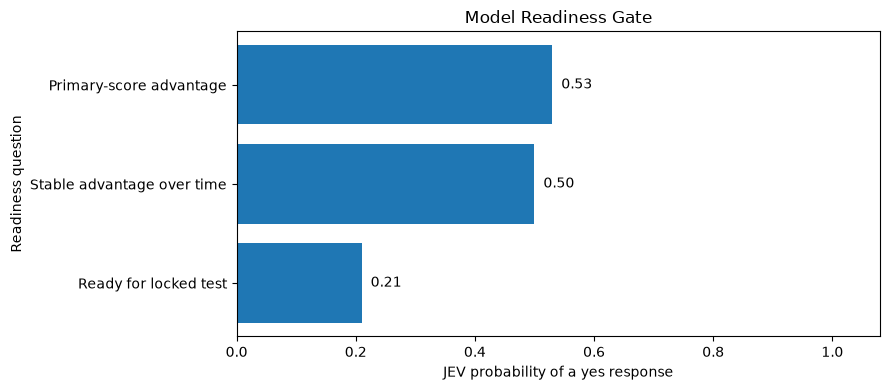

In [19]:
gate_questions = (
    ("Primary-score advantage", "any_model_has_primary_metric_advantage"),
    ("Stable advantage over time", "any_model_has_stable_temporal_advantage"),
    ("Ready for locked test", "any_model_ready_for_locked_test"),
)
gate_labels = [label for label, _ in gate_questions]
gate_values = [noul(question_id) for _, question_id in gate_questions]
fig, ax = plt.subplots(figsize=(9, 4))
positions = range(len(gate_labels))
ax.barh(positions, gate_values)
ax.set_yticks(list(positions), gate_labels)
ax.invert_yaxis()
ax.set_xlim(0, 1.08)
ax.set_xlabel("JEV probability of a yes response")
ax.set_ylabel("Readiness question")
ax.set_title("Model Readiness Gate")
for position, value in zip(positions, gate_values):
    ax.text(value + 0.015, position, f"{value:.2f}", va="center")
fig.tight_layout()
plt.show()
plt.close(fig)

The locked test remains sealed. This notebook read only the saved status metadata and did not open target rows, calculate test scores, or generate test predictions.

## 14. Overall Assessment

For 3D Lotto, the logistic model's complete-draw score was worse than the fair and historical baselines. Digit overlap looked better than fair random, but it was a secondary measure. Shrinkage moved historical estimates closer to fair without beating it.

For Lotto 6/42, the logistic model's average hit count was higher, but its advantage was uncertain and its per-number probabilities were poorly calibrated. The random forest showed only a weak, unstable pattern. Shrinkage improved the historical model without beating the fair complete-set score. The small mutual-information result did not translate into better complete-draw predictions.

The saved Phase 6B assessment is **NO_TESTED_MODEL_READY**. Some small or weak historical patterns were observed, but none of the tested methods demonstrated a reliable improvement in predicting the complete next draw. This does not show that no signal exists or that lottery prediction is impossible.

## 15. Limitations

- JEV is an evidence reviewer, not scientific ground truth.
- The conclusion applies to the methods tested and the historical data available for development and validation.
- The locked test remains unused, so it cannot confirm or overturn these development findings.
- Some JEV answers remain uncertain, especially the 0.53 primary-score gate and the 0.50 time-stability gate.
- The results should not be generalized beyond these tested data and methods.

The notebook is limited to saved aggregate evidence. It does not make predictions or recommend lottery numbers.